# Overview

## 1. Initialization
In this section, we import the necessary libraries used for number manipulation, visualization, preprocessing, model selection, model evaluation, hypertuning, and others that will be used in this notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.stats import randint, uniform, linregress
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import spearmanr, mannwhitneyu
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import shap

## 2. Load the data
In loading the data, we perform the following steps:
1. Connecting to Google Drive
2. Import the dataset and convert it from csv to a dataframe.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd '/content/drive/MyDrive/Internship_Application/Projects/Airline_Customer_Satisfaction'

/content/drive/MyDrive/Internship_Application/Projects/Airline_Customer_Satisfaction


In [ ]:
from pathlib import Path
PATH = Path.cwd() / 'input'

df = pd.read_csv(PATH / 'Invistico_Airline.csv')
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


## 3. Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

From the information above, we can observe the following:
- the shape of the dataframe is `(129880, 23)`;
- all columns have no null values except for `Arrival Delay in Minutes`; and
- the data types present in the dataset are `float64`, `int64`, and `object`.

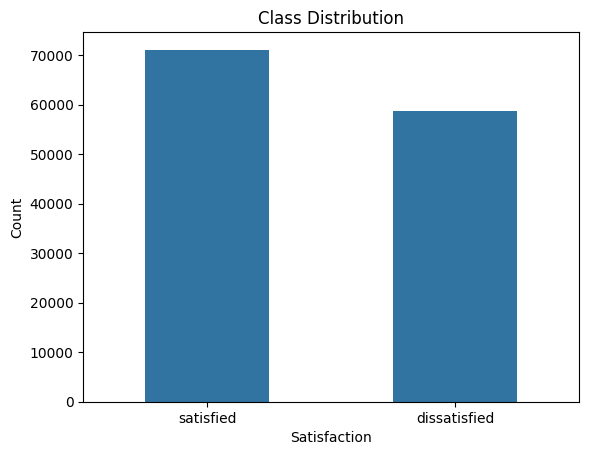

In [ ]:
sns.countplot(data = df, x='satisfaction', width=0.5)
plt.title('Class Distribution')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.show()

In [ ]:
df['satisfaction'].value_counts(normalize=True)

,proportion
satisfaction,
satisfied,0.547328
dissatisfied,0.452672


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum()

,0
satisfaction,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0


We can confirm that `Arrival Delay in Minutes` is the only feature with null values.

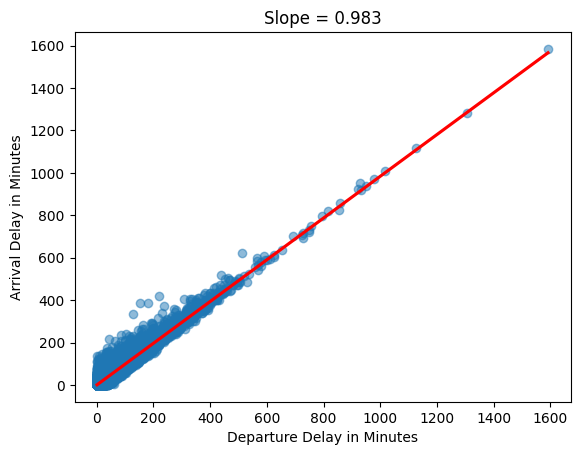

In [ ]:
adimnan = df['Arrival Delay in Minutes'].isnull()

df_temp = df[~adimnan]

adim0 = df_temp['Departure Delay in Minutes'] != 0
ddim0 = df_temp['Arrival Delay in Minutes'] != 0

df_temp = df_temp[(adim0) & (ddim0)]

slope, intercept = np.polyfit(
    df_temp['Departure Delay in Minutes'],
    df_temp['Arrival Delay in Minutes'],
    1
)

sns.regplot(
    x='Departure Delay in Minutes',
    y='Arrival Delay in Minutes',
    data=df_temp,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},

)
plt.title(f'Slope = {slope:.3f}')
plt.show()

The regression plot above between `Departure Delay in Minutes` and `Arrival Delay in Minutes` shows that the two features have an almost linear relationship with slope approx. equal to 1. Thuss, we can replace the null values in `Arrival Delay in Minutes` with values in `Departure Delay in Minutes`.

In [ ]:
df.drop(columns=['Arrival Delay in Minutes'], inplace=True)
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,4,2,3,3,0,3,5,3,2,0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,2,3,4,4,4,2,3,2,310
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,0,2,2,3,3,4,4,4,2,0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,4,3,1,1,0,1,4,1,3,0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,3,4,2,2,0,2,4,2,5,0


In [ ]:
df.nunique()

,0
satisfaction,2
Gender,2
Customer Type,2
Age,75
Type of Travel,2
Class,3
Flight Distance,5398
Seat comfort,6
Departure/Arrival time convenient,6
Food and drink,6


Using `df.nunique()` and looking at `df.info()`, we can conclude that there are three types of features namely categorical `(cat_vars)`, ordinal `(ord_vars)`, and numerical `(num_vars)`.

In [ ]:
target = 'satisfaction'
cat_vars = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
ord_vars = ['Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking',
            'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding']
num_vars = ['Age', 'Flight Distance', 'Departure Delay in Minutes']

Before exploring the dataset, we first need to encode the `'satisfaction'` and `cat_vars` for easier manipualtion and visualization.

In [ ]:
cat_order = {
    'Gender': [['Female', 'Male']],
    'Customer Type': [['disloyal Customer', 'Loyal Customer']],
    'Type of Travel': [['Personal Travel', 'Business travel']],
    'Class': [['Eco', 'Eco Plus', 'Business']]
}

for var in cat_vars:
    oe = OrdinalEncoder(categories=cat_order.get(var), dtype=np.int8)
    df[var] = oe.fit_transform(df[[var]])
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes
0,satisfied,0,1,65,0,0,265,0,0,0,...,4,2,3,3,0,3,5,3,2,0
1,satisfied,1,1,47,0,2,2464,0,0,0,...,2,2,3,4,4,4,2,3,2,310
2,satisfied,0,1,15,0,0,2138,0,0,0,...,0,2,2,3,3,4,4,4,2,0
3,satisfied,0,1,60,0,0,623,0,0,0,...,4,3,1,1,0,1,4,1,3,0
4,satisfied,0,1,70,0,0,354,0,0,0,...,3,4,2,2,0,2,4,2,5,0


In [ ]:
df['satisfaction'] = df['satisfaction'].apply(lambda x: 1 if x == 'satisfied' else 0)
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes
0,1,0,1,65,0,0,265,0,0,0,...,4,2,3,3,0,3,5,3,2,0
1,1,1,1,47,0,2,2464,0,0,0,...,2,2,3,4,4,4,2,3,2,310
2,1,0,1,15,0,0,2138,0,0,0,...,0,2,2,3,3,4,4,4,2,0
3,1,0,1,60,0,0,623,0,0,0,...,4,3,1,1,0,1,4,1,3,0
4,1,0,1,70,0,0,354,0,0,0,...,3,4,2,2,0,2,4,2,5,0


## 4. Exploratory Data Analysis

In [ ]:
def n_row(var_list):
    return np.ceil(len(var_list) / n_cols).astype(int)

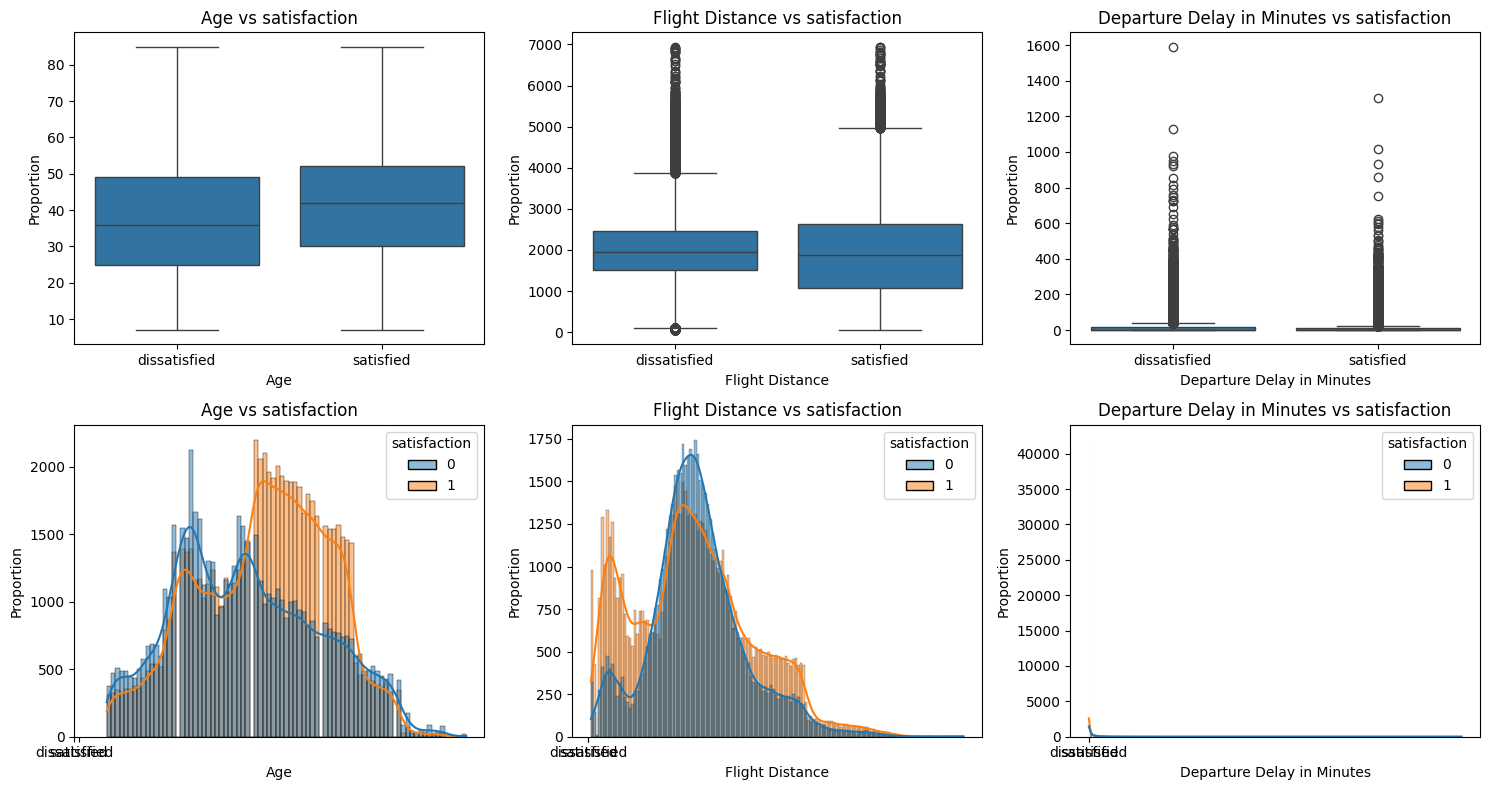

In [ ]:
n_cols = 3
n_rows = n_row(num_vars)

plt.figure(figsize=(n_cols*5, n_rows*4*2))

sat_labels = ['dissatisfied', 'satisfied']


for i, var in enumerate(num_vars):
    plt.subplot(n_rows*2, n_cols, i+1)
    sns.boxplot(x='satisfaction', y=var, data=df)
    plt.title(f'{var} vs {target}')
    plt.ylabel('Proportion')
    plt.xlabel(var)
    plt.xticks(
        ticks=range(len(sat_labels)),
        labels=sat_labels
    )

for i, var in enumerate(num_vars):
    plt.subplot(n_rows*2, n_cols, i+1+len(num_vars))
    sns.histplot(data=df, x=var, hue='satisfaction', kde=True)
    plt.title(f'{var} vs {target}')
    plt.ylabel('Proportion')
    plt.xlabel(var)
    plt.xticks(
        ticks=range(len(sat_labels)),
        labels=sat_labels
    )

plt.tight_layout()
plt.show()

In [ ]:
df[num_vars].describe()

,Age,Flight Distance,Departure Delay in Minutes
count,129880.000000,129880.000000,129880.000000
mean,39.427957,1981.409055,14.713713
std,15.119360,1027.115606,38.071126
min,7.000000,50.000000,0.000000
25%,27.000000,1359.000000,0.000000
50%,40.000000,1925.000000,0.000000
75%,51.000000,2544.000000,12.000000
max,85.000000,6951.000000,1592.000000


In [ ]:
df[num_vars].skew()

,0
Age,-0.003606
Flight Distance,0.466748
Departure Delay in Minutes,6.821980


According to the boxplots and histogram above, the numerical variables are right-skewed. Plots for `Departure Delay in Minutes` show large numbers of outliers and a long right tail. `Flight Distance` is also right-skewed albeit not as heavily as the previous two features. `Age` however, has the least skewed with distibution slightly to the left.

In [ ]:
quantile_scaler = QuantileTransformer(output_distribution='normal', random_state=42)
df['Transformed Departure Delay'] = quantile_scaler.fit_transform(df[['Departure Delay in Minutes']])

pd.Series(df['Transformed Departure Delay']).skew()

np.float64(0.31173458916995966)

In [ ]:
df['Transformed Flight Distance'] = np.power(df['Flight Distance'], 0.73)
pd.Series(df['Transformed Flight Distance']).skew()

np.float64(0.0009026386738723332)

In [ ]:
num_vars.extend(['Transformed Departure Delay','Transformed Flight Distance'])
num_vars.remove('Departure Delay in Minutes')
num_vars.remove('Flight Distance')

Measures taken:
- Since `Age` has a low absolute value of skewness, no transformation is needed.
- `Flight Distance` has a skewness score of $0.4667$. Thus, we will use a fractional power transformation. We found $0.73$ to be the optimal exponent which gives the transformed variable a skewness of $0.0009$.
- We transform `Departure Delay in Minutes` using the Quantile transformer method due to its heavy skewness. After transformation, it now has a skewness value of $0.3117$.
- The original features are dropped leaving the transformed versions.

The boxplots and histogram for our numerical variables are shown below.

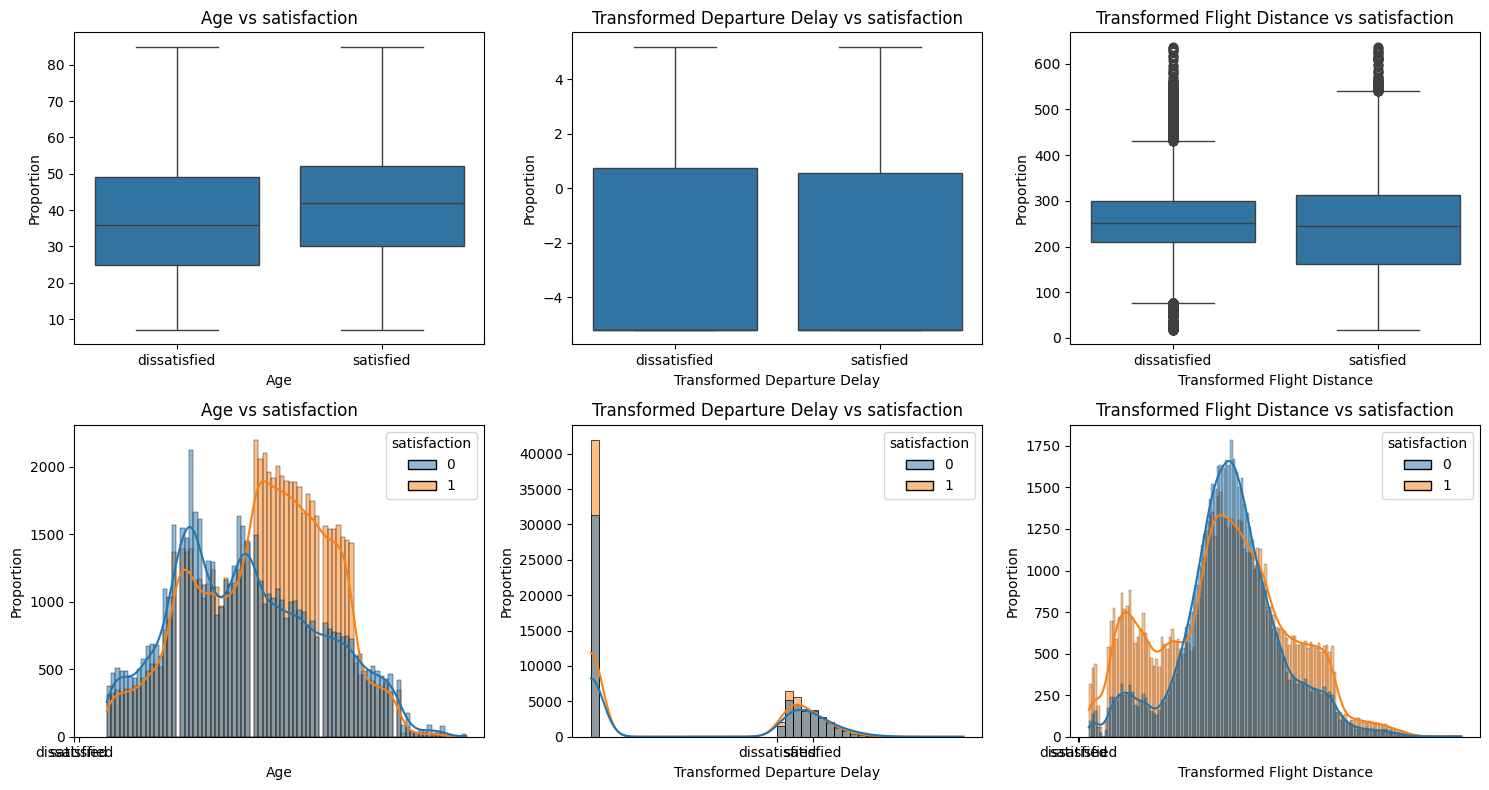

In [ ]:
n_cols = 3
n_rows = n_row(num_vars)

plt.figure(figsize=(n_cols*5, n_rows*4*2))

sat_labels = ['dissatisfied', 'satisfied']


for i, var in enumerate(num_vars):
    plt.subplot(n_rows*2, n_cols, i+1)
    sns.boxplot(x='satisfaction', y=var, data=df)
    plt.title(f'{var} vs {target}')
    plt.ylabel('Proportion')
    plt.xlabel(var)
    plt.xticks(
        ticks=range(len(sat_labels)),
        labels=sat_labels
    )

for i, var in enumerate(num_vars):
    plt.subplot(n_rows*2, n_cols, i+1+len(num_vars))
    sns.histplot(data=df, x=var, hue='satisfaction', kde=True)
    plt.title(f'{var} vs {target}')
    plt.ylabel('Proportion')
    plt.xlabel(var)
    plt.xticks(
        ticks=range(len(sat_labels)),
        labels=sat_labels
    )

plt.tight_layout()
plt.show()

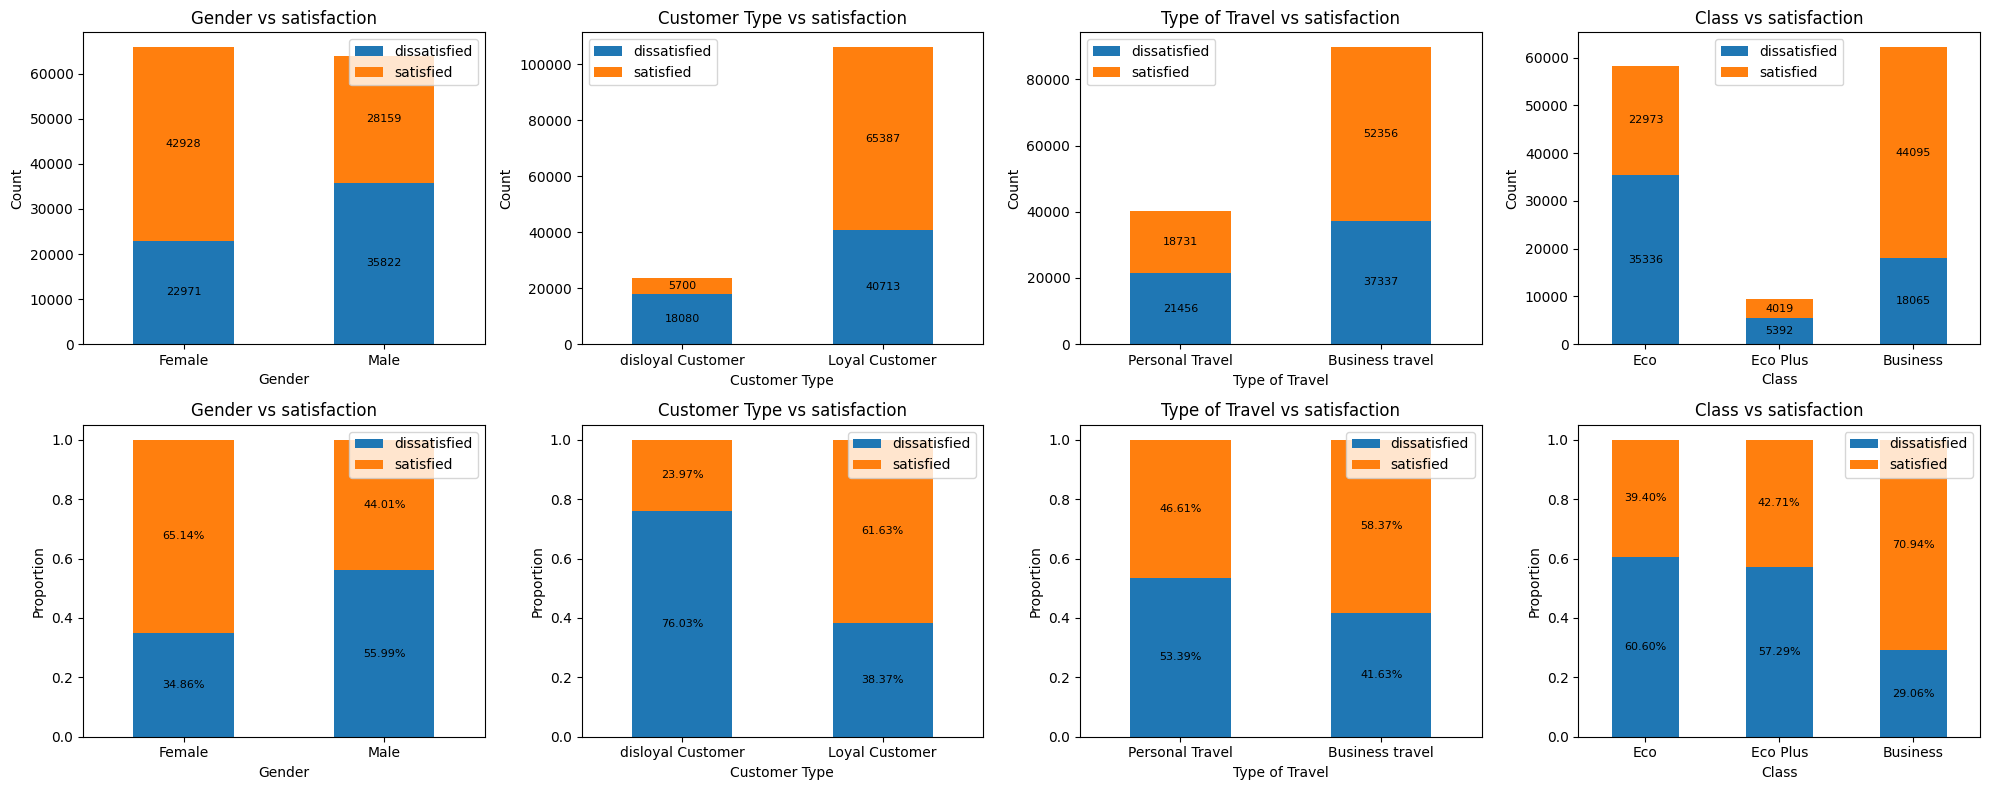

In [ ]:
n_cols = 4
n_rows = n_row(cat_vars)

plt.figure(figsize=(n_cols*5, n_rows*4*2))

for i, var in enumerate(cat_vars):
    ax = plt.subplot(n_rows*2, n_cols, i+1)

    count = pd.crosstab(df[var], df[target])

    count.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='center', fontsize=8)

    plt.title(f'{var} vs {target}')
    plt.legend(labels=['dissatisfied', 'satisfied'])
    plt.ylabel('Count')
    plt.xlabel(var)
    plt.xticks(
        ticks=range(len(cat_order.get(var)[0])),
        labels=cat_order.get(var)[0],
        rotation=0
    )

for i, var in enumerate(cat_vars):
    ax = plt.subplot(n_rows*2, n_cols, i+1+len(cat_vars))

    prop = pd.crosstab(df[var], df[target], normalize='index')

    prop.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    for container in ax.containers:
        labels = [f'{v:.2%}' if v > 0 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

    plt.title(f'{var} vs {target}')
    plt.legend(labels=['dissatisfied', 'satisfied'])
    plt.ylabel('Proportion')
    plt.xlabel(var)
    plt.xticks(
        ticks=range(len(cat_order.get(var)[0])),
        labels=cat_order.get(var)[0],
        rotation=0
    )

plt.tight_layout()
plt.show()

Categorical variables in the dataset include `Gender`, `Customer Type`, `Type of Travel`, and `Class`. The frequency of male $(49.27\%)$ and female $(50.73\%)$ customers are highly balanced. Closer examination shows that while the distribution of satisfied $(44.01\%)$ and dissatisfied $(55.99\%)$ male customers are balanced, there is an imbalance in the level of satisfaction among female customers (satisfied: $65.14\%$; dissatisfied: $34.86\%$).
<br>
<br>
`Customer Type` is divided into two categories where there is a high disparity between the number of `loyal` $(81.70\%)$ and `disloyal` $(18.31\%)$ customers. Notably, a larger proportion of `loyal customers` are satisfied $(61.63\%)$ than they are dissatisfied (38.37\%). `Disloyal customers` exhibit the opposite trend, with satisfied individuals $(23.97\%)$ representing a smaller share than their dissatisfied counterparts $(76.03\%)$. This may suggest that the benefits of being a loyal customer has a positive effect on customer satisfaction and this categorical variable may have importance in predicting satisfaction.
<br>
<br>
Although a notable imbalance is present within the distribution of the `Type of Travel` feature, the level of customer satisfaction remains highly balanced across each travel category.
<br>
<br>
For the `Class` feature, *Eco* $(58,309)$ and *Business* $(62,160)$ have significantly higher numbers than customers in *Eco Plus* $(9,411)$. However, both *Eco* and *Eco Plus* have similar satisfaction distributions which are slightly balanced, *Business* class customers have an overwhelming number of satisfied customers with $70.64\%$. We can infer from this information that seating in *Business* class also has influence in predicting customer satisfaction.

In [ ]:
df['In Business Class'] = df['Class'].apply(lambda x: 1 if x == 2 else 0)
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Transformed Departure Delay,Transformed Flight Distance,In Business Class
0,1,0,1,65,0,0,265,0,0,0,...,3,0,3,5,3,2,0,-5.199338,58.744808,0
1,1,1,1,47,0,2,2464,0,0,0,...,4,4,4,2,3,2,310,2.849703,299.155997,1
2,1,0,1,15,0,0,2138,0,0,0,...,3,3,4,4,4,2,0,-5.199338,269.715324,0
3,1,0,1,60,0,0,623,0,0,0,...,1,0,1,4,1,3,0,-5.199338,109.641830,0
4,1,0,1,70,0,0,354,0,0,0,...,2,0,2,4,2,5,0,-5.199338,72.572550,0


In [ ]:
cat_vars.append('In Business Class')
cat_vars.remove('Class')
df.drop(columns=['Class'], inplace=True)
cat_order['In Business Class'] = [[0, 1]]

We identified specific patterns suggesting that seating class is a significant driver of customer satisfaction. To better capture this relationship and potentially improve model performance, we engineered a new feature: `In Business Class`, a binary indicator derived from the `Class` variable. Instead of dividing the customers between *Economy*, *Economy Plus*, and *Business* class, this will be a variable indicating whether they are in Business class or not.

In [ ]:
df['In Business Class'].value_counts(normalize=True)

,proportion
In Business Class,
0,0.521404
1,0.478596


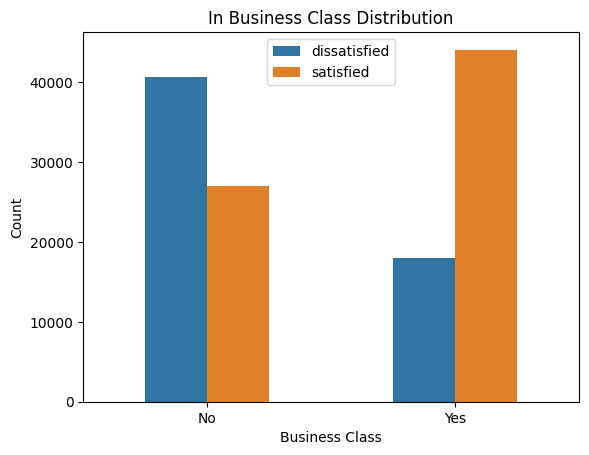

In [ ]:
sns.countplot(data = df, x='In Business Class', width=0.5, hue='satisfaction')
plt.title('In Business Class Distribution')
plt.xticks(ticks=[0,1], labels=['No', 'Yes'])
plt.xlabel('Business Class')
plt.ylabel('Count')
plt.legend(labels=['dissatisfied', 'satisfied'])
plt.show()

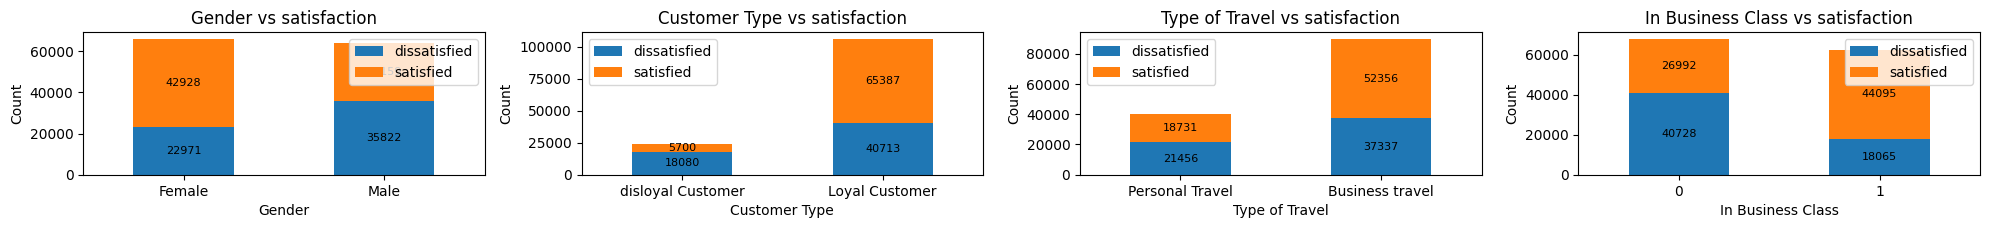

In [ ]:
n_cols = 4
n_rows = n_row(ord_vars)

plt.figure(figsize=(n_cols*5, n_rows*4))

for i, var in enumerate(cat_vars):
    ax = plt.subplot(n_rows*2, n_cols, i+1)

    count = pd.crosstab(df[var], df[target])

    count.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='center', fontsize=8)

    plt.title(f'{var} vs {target}')
    plt.legend(labels=['dissatisfied', 'satisfied'])
    plt.ylabel('Count')
    plt.xlabel(var)
    plt.xticks(
        ticks=range(len(cat_order.get(var)[0])),
        labels=cat_order.get(var)[0],
        rotation=0
    )

plt.tight_layout()
plt.show()

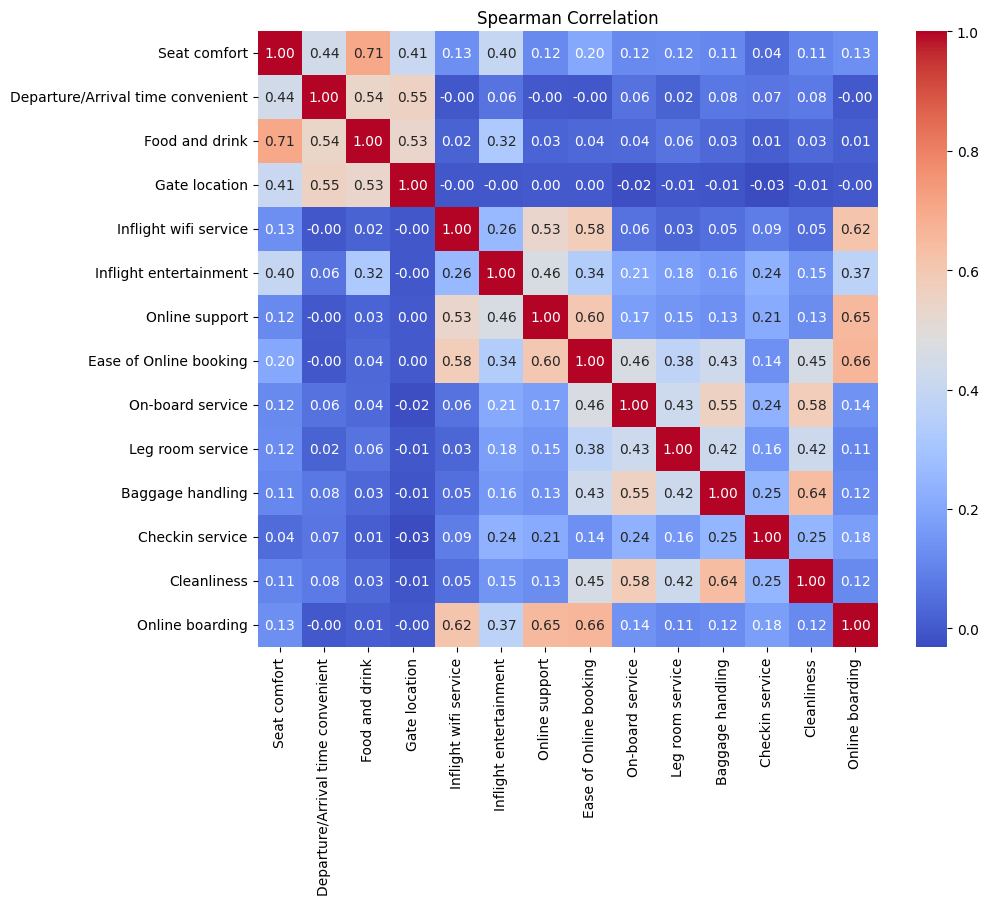

In [ ]:
corr = df[ord_vars].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Spearman Correlation")
plt.show()

## 5. Feature Selection

In selecting features that we will model for predictive analysis, we first engineer features that we think are helpful in building a more robust model. Then, we remove features that provide minimal information about the target feature using Mutual Information. Next, we evaluate the predictor variables for high correlation and eliminate one from each pair to reduce redundancy. We will also explore tree-based feature importance to rank the variables based on their predictive power and ensure that the final model is both accurate and interpretable. It should be noted that since part of the study’s objective is to identify attributes that highly influence customer satisfaction, predictors with Likert scale values are retained as much as possible unless it is deemed insignificant by the aforementioned metrics.


#### Engineered Feature

From our Exploratory Data Analysis, we identified specific patterns suggesting that seating class is a significant driver of customer satisfaction. To better capture these relationships and potentially improve model performance, we engineered a new feature: In Business Class, a binary indicator derived from the Class variable. Instead of dividing the customers between Economy, Economy Plus, and Business class, this will be a variable indicating whether they are in Business class or not. As a consequence, the Class feature will be exclude henceforth.


In [ ]:
sc = StandardScaler()
df[num_vars] = sc.fit_transform(df[num_vars])
df[num_vars].head()

,Age,Transformed Departure Delay,Transformed Flight Distance
0,1.691351,-0.870874,-1.904102
1,0.500820,1.778191,0.521305
2,-1.615680,-0.870874,0.224291
3,1.360648,-0.870874,-1.390624
4,2.022054,-0.870874,-1.764600


In [ ]:
features = ord_vars + num_vars + cat_vars

In [ ]:
X = df[features]
y = df[target]

mi = mutual_info_classif(X, y, random_state=42)

mi_scores = (
    pd.DataFrame({
        'MI_score': mi
    }, index=X.columns)
    .sort_values(by='MI_score', ascending=False)
)

# Rank based on MI score
mi_scores['mi_rank'] = np.arange(1, len(mi_scores) + 1)

print(mi_scores)

                                   MI_score  mi_rank
Inflight entertainment             0.235100        1
Seat comfort                       0.142397        2
Ease of Online booking             0.111713        3
Online support                     0.100630        4
On-board service                   0.071129        5
Online boarding                    0.066401        6
In Business Class                  0.061589        7
Leg room service                   0.061265        8
Customer Type                      0.055863        9
Baggage handling                   0.054720       10
Cleanliness                        0.053809       11
Checkin service                    0.046077       12
Food and drink                     0.038378       13
Inflight wifi service              0.035550       14
Gender                             0.031445       15
Transformed Flight Distance        0.026129       16
Age                                0.024921       17
Type of Travel                     0.018140   

In [ ]:
features.remove('Departure/Arrival time convenient')
features.remove('Gate location')
features.remove('Transformed Departure Delay')
features.remove('Type of Travel')

In [ ]:
mi_scores.drop(index=['Departure/Arrival time convenient', 'Gate location', 'Transformed Departure Delay', 'Type of Travel'], inplace=True)
mi_scores

,MI_score,mi_rank
Inflight entertainment,0.235100,1
Seat comfort,0.142397,2
Ease of Online booking,0.111713,3
Online support,0.100630,4
On-board service,0.071129,5
Online boarding,0.066401,6
In Business Class,0.061589,7
Leg room service,0.061265,8
Customer Type,0.055863,9
Baggage handling,0.054720,10


Mutual information scores help us filter out noise in the dataset by calculating the statistical dependence between each predictor variable and the target variable, satisfaction. Based on the calculated scores presented in Table 3, we establish a threshold of 0.02 to identify and remove weak predictors. Consequently, features such as Gate location $(0.011654)$, Transformed Departure Delay $(0.007430)$, and Departure/Arrival time convenient $(0.003929)$ are dropped from further analysis due to their negligible mutual information with the target. We retain the remaining variables, including high-scoring features like Inflight entertainment $(0.237109)$, Ease of Online booking $(0.113404)$, Seat comfort $(0.143333)$, and Type of Travel $(0.018140)$, for deeper investigation and subsequent model training.

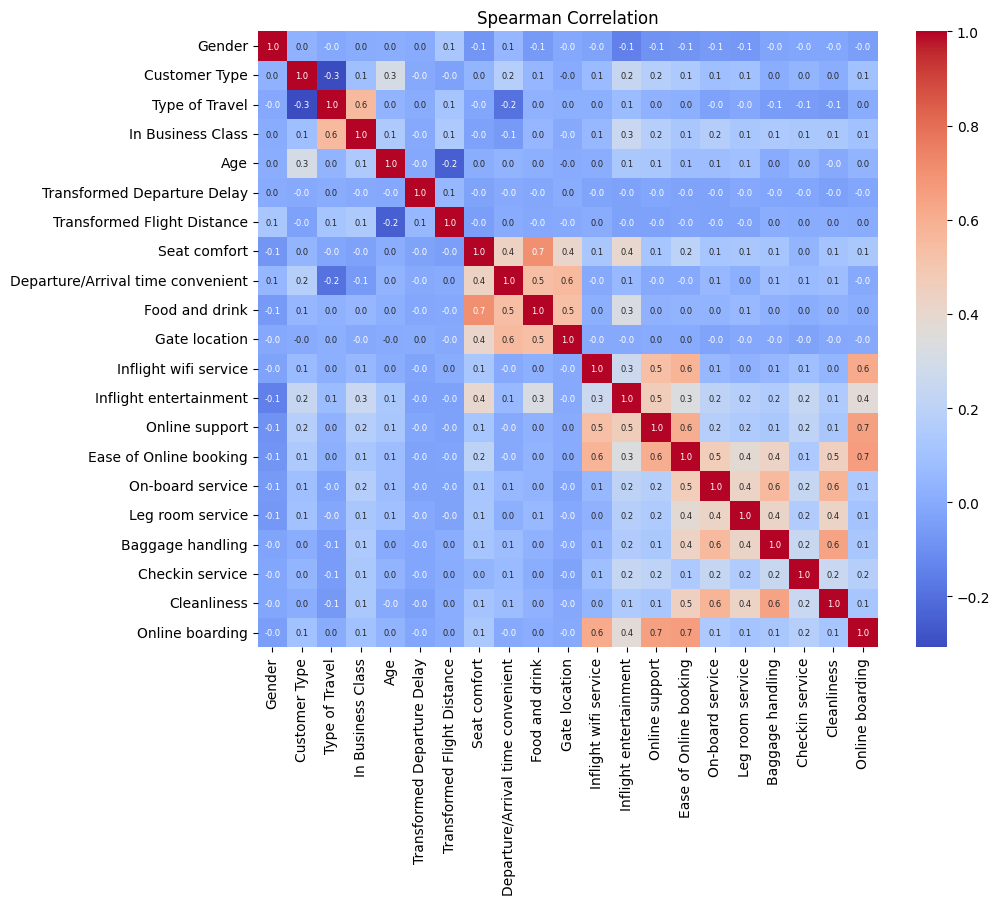

In [ ]:
corr = df[cat_vars + num_vars + ord_vars].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, annot_kws={"size": 6}, cmap='coolwarm', fmt='.1f')
plt.title("Spearman Correlation")
plt.show()

For each type of feature, there are no highly correlated variables. Specifically, an evaluation of the ordinal, numerical, and categorical features indicates that none exhibit an absolute correlation coefficient larger than 0.8. Thus, all variables are retained for further investigation, and no features are dropped at this stage of the analysis.


In [ ]:
X = df[features]
y = df[target]

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

rf_importance = (
    pd.DataFrame({
        'rf_importance': rf.feature_importances_
    }, index=X.columns)
    .sort_values(by='rf_importance', ascending=False)
)

rf_importance['rf_rank'] = np.arange(1, len(rf_importance) + 1)

print(rf_importance)

                             rf_importance  rf_rank
Inflight entertainment            0.228013        1
Seat comfort                      0.144815        2
Ease of Online booking            0.077623        3
Online support                    0.065307        4
Transformed Flight Distance       0.052377        5
Leg room service                  0.046673        6
On-board service                  0.046615        7
Age                               0.045674        8
Food and drink                    0.045625        9
Customer Type                     0.040885       10
In Business Class                 0.039911       11
Online boarding                   0.036012       12
Checkin service                   0.027988       13
Baggage handling                  0.027417       14
Gender                            0.027303       15
Cleanliness                       0.026392       16
Inflight wifi service             0.021369       17


In [ ]:
lgbm = LGBMClassifier(importance_type='gain', random_state=42)
lgbm.fit(X, y)

lgbm_importance = (
    pd.DataFrame({
        'lgbm_importance': lgbm.feature_importances_
    }, index=X.columns)
    .sort_values(by='lgbm_importance', ascending=False)
)

lgbm_importance['lgbm_rank'] = np.arange(1, len(lgbm_importance) + 1)

print(lgbm_importance)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 71087, number of negative: 58793
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 129880, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.547328 -> initscore=0.189882
[LightGBM] [Info] Start training from score 0.189882
                             lgbm_importance  lgbm_rank
Inflight entertainment         315208.391457          1
Seat comfort                   165807.005291          2
Ease of Online booking          55610.548184          3
Customer Type                   30441.650558          4
In Business Class               27013.994981          5
Leg room service            

Tree-based algorithms, including Random Forest and LightGBM provide a robust mechanism for assessing feature importance by analyzing how much each predictor contributes to reducing variance or impurity across the construction of decision trees. During model training, these algorithms calculate the total decrease in node impurity attributed to each feature, providing a clear ranking of which variables most strongly influence the target outcome, satisfaction. By aggregating these importance scores, we can identify and select the most impactful predictors, ensuring that our final model focuses on the variables that drive meaningful patterns in the dataset, while discarding those that contribute little to predictive power.

In [ ]:
merged = pd.concat([mi_scores[['mi_rank']], rf_importance[['rf_rank']], lgbm_importance[['lgbm_rank']]], axis=1)
merged['Total'] = merged.sum(axis=1)
merged.sort_values(by='Total', inplace=True)
merged

,mi_rank,rf_rank,lgbm_rank,Total
Inflight entertainment,1,1,1,3
Seat comfort,2,2,2,6
Ease of Online booking,3,3,3,9
Online support,4,4,8,16
Leg room service,8,6,6,20
In Business Class,7,11,5,23
Customer Type,9,10,4,23
On-board service,5,7,12,24
Food and drink,13,9,7,29
Online boarding,6,12,15,33


We used a Borda Count system in choosing our predictors for modeling. First, we rank our features based on their MI score, Random Forest importance, LightGBM importance, and XGBoost importance. Then, we sum the ranks for each feature (e.g., a feature ranked 2nd, 1st, and 4th gets a score of 7). Finally, select the features with the lowest total rank scores resulting in Table 4.


In [ ]:
df['Cleanliness'].value_counts(normalize=True)

,proportion
Cleanliness,
4,0.375693
5,0.276532
3,0.184663
2,0.103265
1,0.059809
0,0.000038


In [ ]:
df['Mod Cleanliness'] = df['Cleanliness'].apply(lambda x: 1 if x > 3 else 0)
df['Mod Cleanliness'].value_counts(normalize=True)

,proportion
Mod Cleanliness,
1,0.652225
0,0.347775


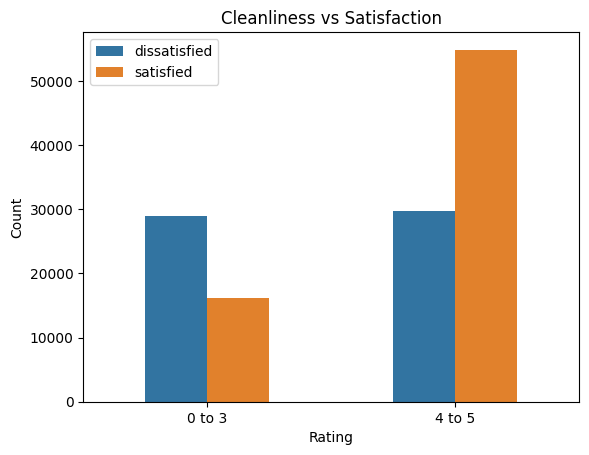

In [ ]:
sns.countplot(data=df, x='Mod Cleanliness', hue='satisfaction', width=0.5)
plt.title('Cleanliness vs Satisfaction')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['0 to 3', '4 to 5'])
plt.legend(labels=['dissatisfied', 'satisfied'])
plt.show()

In [ ]:
service_cols = [
    'Cleanliness',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Food and drink',
    'Leg room service'
]

corr = df[service_cols].corr(method='spearman')

print(corr['Cleanliness'].sort_values(ascending=False))

Cleanliness               1.000000
On-board service          0.578839
Leg room service          0.422882
Inflight entertainment    0.147022
Seat comfort              0.106344
Food and drink            0.033133
Name: Cleanliness, dtype: float64


From our result, we will keep features in the top 12 of the Borda Count system which mainly includes Likert scale variables such as Inflight entertainment, Seat comfort, and Ease of Online booking. The categorical features Customer Type and In Business Class that we expected to have importance during the EDA are also in the top 12. Transformed Flight Distance, Age, Gender, and Inflight wifi service were excluded from the final feature set because they consistently exhibited relatively low importance across Mutual Information, Random Forest, and LightGBM, indicating limited contribution to predicting customer satisfaction compared with the other variables. Although Cleanliness also received a relatively low overall ranking, it was retained because further analysis demonstrated a clear association between Cleanliness ratings and customer satisfaction, and it achieved a moderate ranking in Mutual Information. Its lower importance in the tree-based models is likely attributable to shared predictive information with other service-related features rather than a lack of relevance. Therefore, Cleanliness was retained to preserve a meaningful service quality indicator in the final model.


In [ ]:
predictors = ['Inflight entertainment', 'Seat comfort', 'Ease of Online booking', 'Online support', 'Leg room service',
              'In Business Class', 'Customer Type', 'On-board service', 'Food and drink', 'Online boarding',
              'Checkin service', 'Baggage handling', 'Cleanliness']

## 6. Modeling

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

In [ ]:
X = df[predictors]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ('classifier', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    print(f'{name} done!')
# Runtime approx. 1.5 min

Logistic Regression done!
Random Forest done!
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 56870, number of negative: 47034
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 70
[LightGBM] [Info] Number of data points in the train set: 103904, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.547332 -> initscore=0.189897
[LightGBM] [Info] Start training from score 0.189897
LightGBM done!


In [ ]:
results_df = (
    pd.DataFrame(results)
      .sort_values(by="F1-score", ascending=False)
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
1        Random Forest  0.941022   0.948709  0.943237  0.945965  0.984956
2             LightGBM  0.935363   0.943478  0.938102  0.940782  0.986333
0  Logistic Regression  0.820219   0.831516  0.842161  0.836805  0.895982


Based on the performance metrics presented in Table 7, the Random Forest model is the overall best performer. While both ensemble methods—Random Forest and LightGBM—significantly outperformed the Logistic Regression baseline, Random Forest achieved higher scores across almost all key metrics:
* Accuracy: Random Forest (0.941022) is slightly higher than LightGBM (0.935363).
* Precision and F1-score: Random Forest shows higher reliability in positive predictions (0.948709 precision) and a stronger harmonic balance between precision and recall (0.945965 F1-score) compared to LightGBM.
* ROC-AUC: While LightGBM holds a very slight edge in its ability to distinguish between classes (0.986333 vs. 0.984956), Random Forest’s consistent lead in accuracy, precision, and F1-score makes it the most robust model for this specific classification task.
<br>

Logistic Regression remains the least effective model across all evaluated metrics, confirming that more sophisticated tree-based algorithms were necessary to capture the complexities of the dataset.


## 7. Hyperparameter Tuning

### 7.1 Random Forest

In [ ]:
# @title
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Parameter distributions
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Stratified CV
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Random Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                 # Try 30 random combinations
    scoring='f1_weighted',     # or 'accuracy', 'roc_auc'
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 406}

Best CV Score:
0.9402554505968062


In [ ]:
# @title
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.943178318447798

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     11759
           1       0.95      0.94      0.95     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976

[[11091   668]
 [  808 13409]]


In [ ]:
# @title
start_time = time.time()

pipeline = Pipeline([
    ("model", best_rf)
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    pipeline,
    X,
    y,
    cv=skf,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

elapsed_time = time.time() - start_time

print(f"Accuracy : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"Precision: {scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}")
print(f"Recall   : {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
print(f"F1 Score : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
print(f"ROC-AUC  : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
print(f"Elapsed Time: {elapsed_time:.2f} seconds")

Accuracy : 0.9422 ± 0.0009
Precision: 0.9522 ± 0.0020
Recall   : 0.9418 ± 0.0007
F1 Score : 0.9469 ± 0.0008
ROC-AUC  : 0.9881 ± 0.0003
Elapsed Time: 312.65 seconds


### 7.2 LightGBM

In [ ]:
# @title
start_time = time.time()

lgbm = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

# Parameter distributions
param_dist = {
    'n_estimators': randint(100, 600),
    'learning_rate': uniform(0.01, 0.19),
    'max_depth': randint(3, 15),
    'num_leaves': randint(20, 150),
    'min_child_samples': randint(10, 100),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 5),
    'reg_lambda': uniform(0, 5)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_weighted',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

elapsed_time = time.time() - start_time

print(random_search_lgbm.best_params_)
print(random_search_lgbm.best_score_)

print(f"Elapsed Time: {elapsed_time:.2f} seconds")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 56870, number of negative: 47034
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 70
[LightGBM] [Info] Number of data points in the train set: 103904, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.547332 -> initscore=0.189897
[LightGBM] [Info] Start training from score 0.189897
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [ ]:
# @title
best_lgbm = random_search_lgbm.best_estimator_

y_pred = best_lgbm.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     11759
           1       0.96      0.94      0.95     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976

[[11141   618]
 [  829 13388]]


In [ ]:
# @title
start_time = time.time()

pipeline = Pipeline([
    ("model", best_lgbm)
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    pipeline,
    X,
    y,
    cv=skf,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

elapsed_time = time.time() - start_time

print(f"Accuracy : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"Precision: {scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}")
print(f"Recall   : {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
print(f"F1 Score : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
print(f"ROC-AUC  : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
print(f"Elapsed Time: {elapsed_time:.2f} seconds")

Accuracy : 0.9441 ± 0.0004
Precision: 0.9546 ± 0.0008
Recall   : 0.9427 ± 0.0011
F1 Score : 0.9486 ± 0.0004
ROC-AUC  : 0.9898 ± 0.0002
Elapsed Time: 103.38 seconds


## 8. Model Evaluation

In [ ]:
# @title
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

    print(pd.Series(metrics))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title("Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_predictions(
        y_test,
        y_proba
    )

    plt.title("ROC Curve")
    plt.show()

    return metrics

Accuracy     0.944526
Precision    0.953693
Recall       0.944503
F1-Score     0.949076
ROC-AUC      0.988760
dtype: float64

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     11759
           1       0.95      0.94      0.95     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



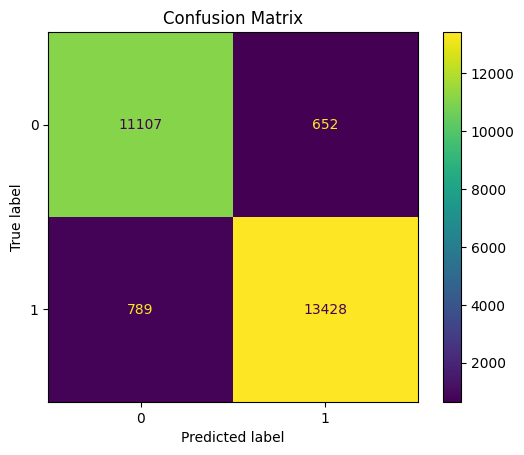

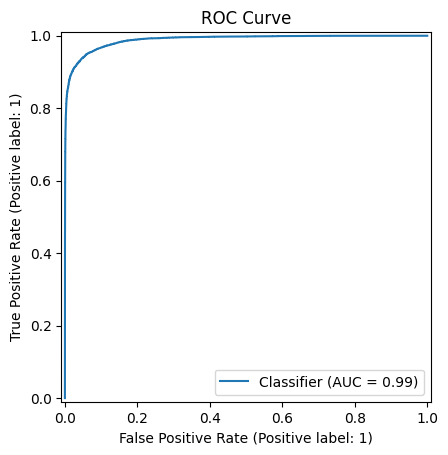

{'Accuracy': 0.9445257160455806,
 'Precision': 0.9536931818181819,
 'Recall': 0.9445030597172399,
 'F1-Score': 0.9490758737675372,
 'ROC-AUC': np.float64(0.9887603552011957)}

In [ ]:
evaluate_model(best_rf, X_test, y_test)

Accuracy     0.944295
Precision    0.955876
Recall       0.941690
F1-Score     0.948730
ROC-AUC      0.989778
dtype: float64

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     11759
           1       0.96      0.94      0.95     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



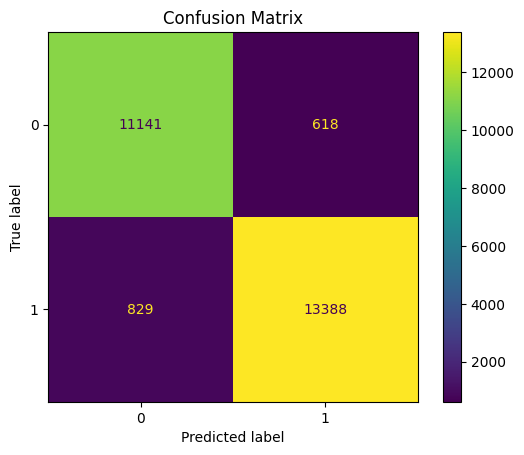

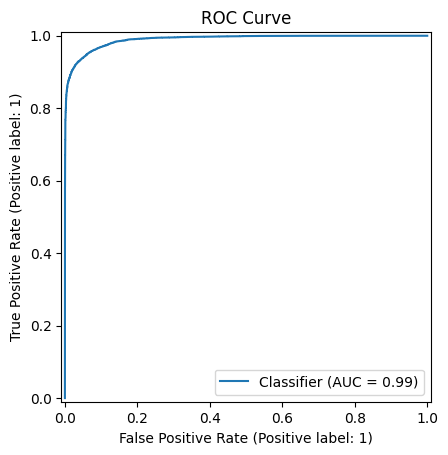

{'Accuracy': 0.9442947336002464,
 'Precision': 0.9558760531200914,
 'Recall': 0.9416895266230569,
 'F1-Score': 0.9487297594160791,
 'ROC-AUC': np.float64(0.989778014834909)}

In [ ]:
evaluate_model(best_lgbm, X_test, y_test)

Despite the performance metrics achieved by the Random Forest model, the LightGBM classifier was selected as the final model for this study. This decision was driven by its superior performance during hyperparameter tuning, where LightGBM achieved a higher cross-validation score. This result demonstrates that LightGBM provides better generalization and robustness, making it the more reliable choice for predicting airline customer satisfaction in a real-world environment.


Furthermore, while the Random Forest model achieves the highest overall performance metrics, relying solely on these aggregate figures can overlook the specific business impact of different error types. In the context of airline customer satisfaction, minimizing false positives—instances where the model incorrectly predicts a passenger as "satisfied" when they are actually "dissatisfied"—is strategically critical. A higher false positive rate creates a dangerous false sense of security, potentially leading the airline to overlook passengers who require service interventions. By prioritizing a model with a lower false positive rate, the airline ensures that it more accurately captures truly dissatisfied customers, allowing for targeted service recovery and effectively mitigating the risk of customer churn that might otherwise go unnoticed.


## 9. Model Interpretation

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_lgbm.feature_importances_
})

importance_df = (
    importance_df
    .sort_values('Importance', ascending=False)
)

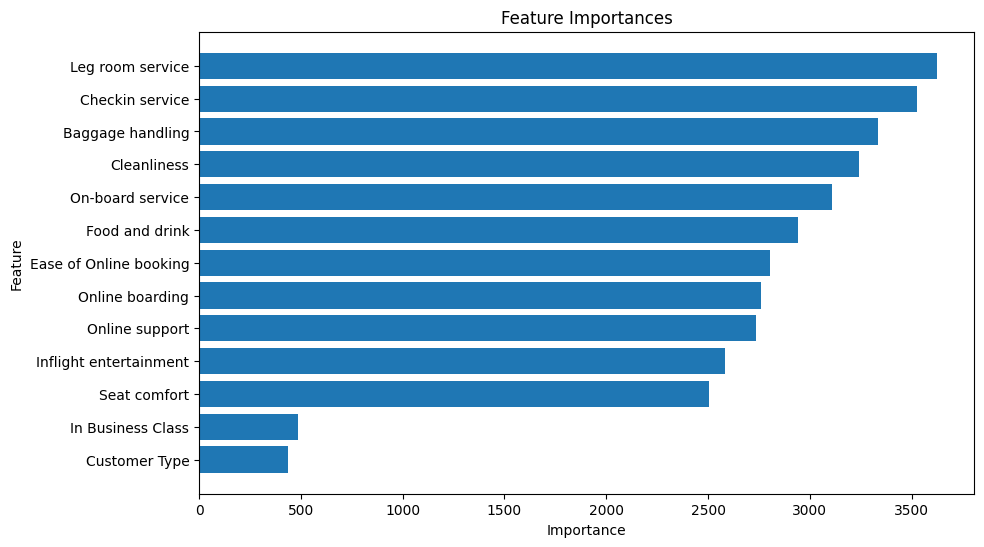

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'][:20][::-1],
    importance_df['Importance'][:20][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.show()

Feature importance analysis provides critical insights into the primary determinants of airline customer satisfaction. As visualized in Figure 10, the model indicates that service attributes related to inflight experience and pre-flight digital touchpoints exert the strongest influence on predictive outcomes. Specifically, features such as seat comfort, inflight entertainment, and ease of online booking emerge as robust drivers of customer satisfaction. While tree-based importance highlights the significant contribution of operational metrics like leg room and check-in services, the SHAP interpretation confirms that positive ratings across core passenger experiences—particularly in comfort and entertainment—are the most reliable indicators of a satisfied passenger, whereas inconsistencies or low scores in these areas consistently push the model toward predicting dissatisfaction.


Interestingly, the features In Business Class and Customer Type exhibit relatively low importance scores in the final model, despite initial trends observed during Exploratory Data Analysis. This discrepancy suggests that while these high-level categorical factors are associated with satisfaction, specific operational service attributes—such as seating comfort and digital touchpoint quality—are much more powerful and direct drivers of passenger feedback. Ultimately, the model indicates that the quality of the actual service delivery carries significantly more weight in determining customer satisfaction than broad passenger-level demographic or booking class information.


In [ ]:
explainer = shap.Explainer(best_lgbm)
shap_values = explainer(X_test)

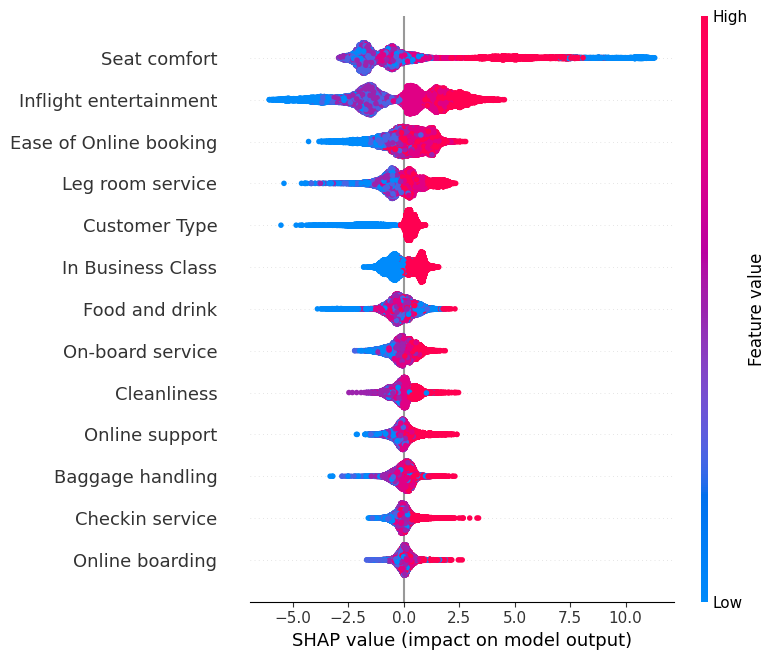

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

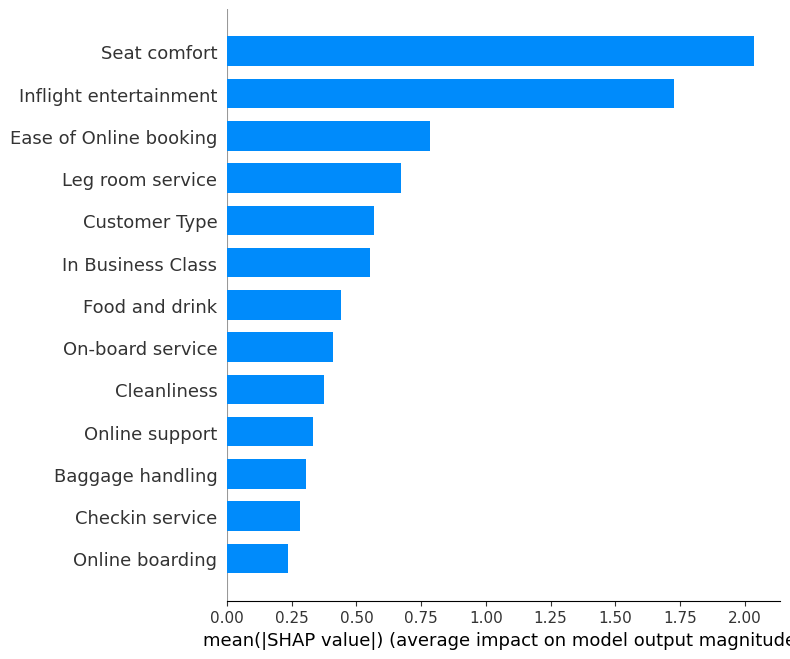

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

In [ ]:
y_pred = best_lgbm.predict(X_test)

errors = X_test.copy()

errors['Actual'] = y_test.values
errors['Predicted'] = y_pred

misclassified = errors[
    errors['Actual'] != errors['Predicted']
]

print("Misclassified cases:", len(misclassified))

Misclassified cases: 1447


In [ ]:
misclassified.head()

,Inflight entertainment,Seat comfort,Ease of Online booking,Online support,Leg room service,In Business Class,Customer Type,On-board service,Food and drink,Online boarding,Checkin service,Baggage handling,Cleanliness,Actual,Predicted
86893,4,4,4,1,3,1,1,4,4,1,1,4,4,1,0
96818,4,3,2,4,3,1,1,3,3,4,4,4,1,1,0
60006,4,4,4,4,1,0,0,5,4,4,2,1,4,0,1
57041,4,4,2,2,5,0,0,2,4,2,5,1,4,0,1
92877,4,4,2,4,1,1,1,4,5,4,4,1,4,0,1


In [ ]:
correct = errors[
    errors['Actual'] == errors['Predicted']
]

misclassified = errors[
    errors['Actual'] != errors['Predicted']
]

In [ ]:
comparison = pd.DataFrame({
    'Correct Mean': correct.mean(numeric_only=True),
    'Misclassified Mean': misclassified.mean(numeric_only=True)
})

comparison.head(20)

,Correct Mean,Misclassified Mean
Inflight entertainment,3.359248,3.682101
Seat comfort,2.788944,3.636489
Ease of Online booking,3.484162,3.301313
Online support,3.534306,3.334485
Leg room service,3.496840,3.342778
In Business Class,0.488361,0.281963
Customer Type,0.819561,0.765031
On-board service,3.474092,3.323428
Food and drink,2.807330,3.545266
Online boarding,3.365078,3.254319


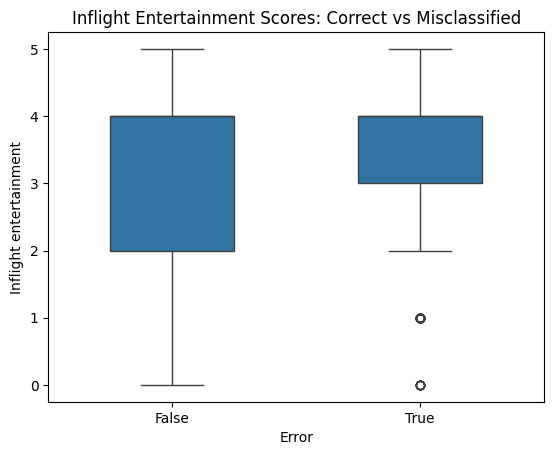

In [ ]:
errors['Error'] = (
    errors['Actual'] != errors['Predicted']
)

sns.boxplot(
    data=errors,
    x='Error',
    y='Inflight entertainment',
    width=0.5
)

plt.title(
    'Inflight Entertainment Scores: Correct vs Misclassified'
)

plt.show()

In [ ]:
import joblib

# Save the model
joblib.dump(best_lgbm, 'best_lgbm_model.pkl')

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import json

# Save best parameters
with open('lgbm_best_params.json', 'w') as f:
    json.dump(random_search_lgbm.best_params_, f, indent=4)

# Save CV score
with open('lgbm_cv_score.txt', 'w') as f:
    f.write(f"Best CV Score: {random_search_lgbm.best_score_:.6f}")

In [ ]:
# Load the saved model
loaded_model = joblib.load('best_lgbm_model.pkl')

print("Model loaded successfully.")

In [ ]:
# Predict class labels
y_pred = loaded_model.predict(X_test)

# Predict class probabilities
y_proba = loaded_model.predict_proba(X_test)[:, 1]

In [ ]:
pipeline = joblib.load('lgbm_pipeline.pkl')

predictions = pipeline.predict(new_data)

# Summary and Conclusion